**The goal** of this competition is to predict which clients are more likely to default on their loans. The evaluation is based on gini stability metric and will favor solutions that are stable over time. A separate chalenge is to deal with large data sizes and constantly monitor and reduce memory usage to not exceed allocated amount of RAM.  

**Structure**

There are several tables classified by 'depth':
* depth=0 - These are static features directly tied to a specific case_id.
* depth=1 - Each case_id has an associated historical record, indexed by num_group1.
* depth=2 - Each case_id has an associated historical record, indexed by both num_group1 and num_group2.

Various predictors were transformed, therefore we have the following notation for similar groups of transformations

* P - Transform DPD (Days past due)
* M - Masking categories
* A - Transform amount
* D - Transform date
* T - Unspecified Transform
* L - Unspecified Transform

Transformations within a group are denoted by a capital letter at the end of the predictor name (e.g., maxdbddpdtollast6m_4187119P)

**Strategy**

Following approach for data processing will be used:
* depth=2 files will be aggregated, grouped by case_id and num_group1. For numerical columns we will calculate the average between num_group2 values and for categoricals we will get the most frequent value. Like this they will become as depth=1 files and the same processing function as for depth=1 files will be applied to them.
* for depth=1 files we will use an aggregation grouped by case_id. For numerical columns we will calculate the mean, std, min and max between num_group1 values. For categoricals we will get the most frequent value. After this the files will become as depth=0.
* at depth=0 level we will merge all the files together on case_id as all the case_id are unique at this level. 

After data analysis, time delta features will be created based on timeseries columns and all the preparations for modeling will be made using a processing pipeline. Competition's stability metric will be integrated during Optuna tuning process and also in the model training as evaluation metric.

In [1]:
pip install scikit-learn --upgrade --no-index --find-links=file:/kaggle/input/sklearn-1-4-1/ 

Looking in links: file:///kaggle/input/sklearn-1-4-1/
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, glob
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample, shuffle
from sklearn.decomposition import PCA
from sklearn.preprocessing import (
    OneHotEncoder, PowerTransformer, 
    TargetEncoder, OrdinalEncoder
)
from sklearn.model_selection import (
    train_test_split, StratifiedGroupKFold
)
from lightgbm import (
    LGBMClassifier, early_stopping, log_evaluation, plot_importance,
)
from xgboost import XGBClassifier, DMatrix
from xgboost.callback import EarlyStopping
from catboost import CatBoostClassifier, Pool

# Use gpu if available
from catboost.utils import get_gpu_device_count
device = 'gpu' if get_gpu_device_count() > 0 else 'cpu'

pd.options.display.max_colwidth = None

#### Pandas functions

In [3]:
def downcast(df):
    """
    Reduce memory usage of a Pandas DataFrame by converting 
    object types to categories and downcasting numeric columns
    """
    # Column types
    object_cols, int_cols, float_cols = [], [], []
    for col, dtype in df.dtypes.items():
        if pd.api.types.is_object_dtype(dtype):
            object_cols.append(col)
        elif pd.api.types.is_integer_dtype(dtype):
            int_cols.append(col)
        elif pd.api.types.is_float_dtype(dtype):
            float_cols.append(col)
        
    # Convert object columns to category
    df[object_cols] = df[object_cols].astype('category')

    # Downcast integer columns
    df[int_cols] = df[int_cols].apply(pd.to_numeric, downcast='integer')
   
    # Downcast float columns
    df[float_cols] = df[float_cols].apply(pd.to_numeric, downcast='float')
        
    return df

def cols_types(df):
    """
    Create lists of feature names dtype
    """
    date_cols, num_cols, cat_cols = [], [], []
    for col, dtype in df.dtypes.items():
        if pd.api.types.is_bool_dtype(dtype):
            cat_cols.append(col)
        elif pd.api.types.is_datetime64_dtype(dtype):
            date_cols.append(col)
        elif pd.api.types.is_numeric_dtype(dtype):
            num_cols.append(col)
        else:
            cat_cols.append(col)
            
    return date_cols, num_cols, cat_cols

#### Polars functions to read and preprocess data
Many aggregation functions are commented out, but available for any experiments

In [4]:
def pl_cols_types(df):
    """
    (Polars version)
    Create lists of feature names dtype
    """
    date_cols, num_cols, cat_cols = [], [], []
    
    num_cols = df.select(pl.col(pl.NUMERIC_DTYPES)).columns
    date_cols = df.select(pl.col(pl.Date)).columns
    cat_cols = [col for col in df.columns 
                if col not in num_cols and col not in date_cols]
            
    return date_cols, num_cols, cat_cols

def aggregate_depth1(df):
    """
    (Polars version)
    Aggregate depth=1 dataframe and return a depth=0 dataframe 
    """
    # Drop 'num_group1' column
    df = df.drop('num_group1')

    # Create aggregation dataframe and count repetitive case_id
    col_to_count = df.columns[1]
    all_agg = df.group_by('case_id').agg(
        pl.col(col_to_count).count().alias(f'{col_to_count}_count')
    )
    # Columns types 
    date_cols, num_cols, cat_cols = pl_cols_types(df)
    num_cols.remove('case_id')

    # Aggregate categorical columns
    if len(cat_cols) > 0:
        for col in cat_cols:
            if not df[col].is_null().all():
                cat_agg = df.group_by('case_id').agg(
                    pl.col(col).drop_nulls().mode().first().alias(f'{col}_mode'),
#                     pl.n_unique(col).alias(f'{col}_n_unique'),
#                     pl.col(col).first().alias(f'{col}_first'),
#                     pl.col(col).drop_nulls().last().alias(f'{col}_last'),
                )
                # Drop aggregated column to free memory
                df = df.drop(col)

                # Merge with aggregated dataframe
                all_agg = all_agg.join(cat_agg, on='case_id', how='left')

                # Free memory
                del cat_agg

    # Aggregate date columns
    if len(date_cols) > 0:
        for col in date_cols:
            date_agg = df.group_by('case_id').agg(
                pl.mean(col).alias(f'{col}_mean'), 
#                 pl.col(col).first().alias(f'{col}_first'),
#                 pl.col(col).drop_nulls().last().alias(f'{col}_last'),
            )
            # Drop aggregated column to free memory
            df = df.drop(col)

            # Merge with aggregated dataframe
            all_agg = all_agg.join(date_agg, on='case_id', how='left')

            # Free memory
            del date_agg

    # Aggregate numeric columns 
    if len(num_cols) > 0:
        for col in num_cols:
            num_agg = df.group_by('case_id').agg(
                pl.mean(col).alias(f'{col}_mean'), 
#                 pl.median(col).alias(f'{col}_median'), 
#                 pl.min(col).alias(f'{col}_min'), 
#                 pl.max(col).alias(f'{col}_max'), 
#                 pl.col(col).first().alias(f'{col}_first'),
#                 pl.col(col).drop_nulls().last().alias(f'{col}_last'),
            )
            # Drop aggregated column to free memory
            df = df.drop(col)

            # Merge with aggregated dataframe
            all_agg = all_agg.join(num_agg, on='case_id', how='left')

            # Free memory
            del num_agg
  
    print('Depth1 aggregation finished')    
    return all_agg

def aggregate_depth2(df):
    """
    (Polars version)
    Aggregate depth=2 dataframe to level depth=1 and then apply 
    aggregate_depth1 function to return a depth=0 dataframe
    """
    df = df.drop('num_group2')
    
    # Columns types
    groupby_cols = ['case_id', 'num_group1']
    date_cols, num_cols, cat_cols = pl_cols_types(df)
    num_cols = [col for col in num_cols if col not in groupby_cols]
    
    # Create aggregation dataframe
    all_agg = df[groupby_cols]
    all_agg = all_agg.unique(groupby_cols, maintain_order=True)
    
    # Aggregate categoricals 
    if len(cat_cols) > 0:
        for col in cat_cols:
            if not df[col].is_null().all():
                cat_agg = df.group_by('case_id').agg(
                    pl.col(col).drop_nulls().mode().first().alias(f'{col}_mode'),
#                     pl.col(col).drop_nulls().first().alias(f'{col}_first'),
                )
                # Drop aggregated column to free memory
                df = df.drop(col)

                # Merge with aggregated dataframe
                all_agg = all_agg.join(cat_agg, on='case_id', how='left')

                # Free memory
                del cat_agg
    
    # Aggregate date columns
    if len(date_cols) > 0:
        for col in date_cols:
            date_agg = df.group_by('case_id').agg(
                pl.mean(col).alias(f'{col}_mean'), 
#                 pl.col(col).drop_nulls().first().alias(f'{col}_first'),
            )
            # Drop aggregated column to free memory
            df = df.drop(col)

            # Merge with aggregated dataframe
            all_agg = all_agg.join(date_agg, on='case_id', how='left')

            # Free memory
            del date_agg
    
    # Aggregate numeric columns if any
    if len(num_cols) > 0:
        for col in num_cols:
            num_agg = df.group_by('case_id').agg(
                pl.mean(col).alias(f'{col}_mean'), 
#                 pl.median(col).alias(f'{col}_median'),
#                 pl.col(col).drop_nulls().first().alias(f'{col}_first'),
            )
            # Drop aggregated column to free memory
            df = df.drop(col)

            # Merge with aggregated dataframe
            all_agg = all_agg.join(num_agg, on='case_id', how='left')

            # Free memory
            del num_agg
 
    del df
    print('Depth2 aggregation finished') 
    return aggregate_depth1(all_agg)

def create_df_from(path, file_name, depth=0):
    """
    (Polars version)
    Preprocess files in chunks 
    """
    dfs = []
    for i, file_path in enumerate(
        glob.glob(path + '*' + file_name + '*.parquet')
    ):
        df = pl.read_parquet(file_path)

        for col in df.columns:
            if (col[-1] == 'D') or (col == 'date_decision'):
                df = df.with_columns(pl.col(col).cast(pl.Date))
            elif col in ['case_id', 'WEEK_NUM', 'num_group1', 'num_group2']:
                df = df.with_columns(pl.col(col).cast(pl.Int32))
            elif 'person' in col:
                df = df.with_columns(
                    pl.col(col).cast(pl.String).cast(pl.Categorical))
            elif 'month' in col and 'T' in col:
                df = df.with_columns(
                    pl.col(col).cast(pl.String).cast(pl.Categorical))
        
        if depth == 2:
            df = aggregate_depth2(df)
            
        elif depth == 1:
            df = aggregate_depth1(df) 

        dfs.append(df)
        print(f'Chunk {i} added to list')
    
    return pl.concat(dfs, how='diagonal_relaxed')

def read_prepare_all(path, files_dict):
    """
    (Polars version)
    Read, preprocess and merge all the files together
    Return a pandas dataframe
    """
    # Read base data frame
    df_all = create_df_from(path, 'base')
    print(f'base created')

    # Read and aggregate 
    for depth, files_list in files_dict.items():
        for file in files_list:
            # Create dataframe from file chunks
            print(f'### Start read {file}')
            df = create_df_from(path, file, depth)
            
            # Join with the main dataframe
            df_all = df_all.join(df, how='left', on='case_id')
            print(f'=== {file} merged to df_all')
            
            # Convert to Categorical to free memory
            df_all = df_all.with_columns(
                pl.col(pl.String).cast(pl.Categorical))
            df_all = df_all.with_columns(
                pl.col(pl.Float64).cast(pl.Float32))
        
    # Free memory
    del df
    
    # Columns types
    date_cols, num_cols, cat_cols = pl_cols_types(df_all)
    
    # Convert to pandas in chunks to not explode memory use
    df_pd = df_all.select(pl.col(num_cols)).to_pandas()
    df_all = df_all.drop(num_cols)
    df_pd = df_pd.join(df_all.select(pl.col(date_cols)).to_pandas())
    df_all = df_all.drop(date_cols)
    df_pd = df_pd.join(df_all.select(pl.col(cat_cols)).to_pandas())
    del df_all
    print('df converted to pandas')
    
    # Create time features
    df_pd['birth_year'] = df_pd.birth_259D_mean.dt.year
    df_pd['decision_year'] = df_pd.date_decision.dt.year
    df_pd['decision_quarter'] = (
        df_pd.date_decision.dt.quarter.astype(str).astype('category'))
    df_pd['decision_month_of_year'] = (
        df_pd.date_decision.dt.month.astype(str).astype('category'))
    df_pd['decision_day_of_month'] = df_pd.date_decision.dt.day
    df_pd['decision_day_of_year'] = df_pd.date_decision.dt.dayofyear
    df_pd['decision_week_of_year'] = df_pd.date_decision.dt.isocalendar().week
    df_pd['decision_day_of_week'] = (
        (df_pd.date_decision.dt.dayofweek + 1).astype(str).astype('category'))
    
    return downcast(df_pd)

#### Read and preprocess data

In [5]:
# Filepaths
main_path = '/kaggle/input/home-credit-credit-risk-model-stability/'
train_path = main_path + 'parquet_files/train/'
test_path = main_path + 'parquet_files/test/'

# Read info files
feat_def = pd.read_csv(main_path + 'feature_definitions.csv')
submit = pd.read_csv(main_path + 'sample_submission.csv')

# Lists of file names
files_dict = {
    0: ['static_0', 'static_cb_0'],
    1: ['credit_bureau_a_1', 'credit_bureau_b_1', 'applprev_1', 
        'debitcard_1', 'deposit_1', 'other_1', 'person_1', 
        'tax_registry_a_1', 'tax_registry_b_1', 'tax_registry_c_1'],
    2: ['credit_bureau_a_2', 'credit_bureau_b_2', 'applprev_2', 'person_2']
}

In [6]:
%%time

# Process / restore point
process = False

if process:
    # Read, preprocess and merge all the training files together
    X = read_prepare_all(train_path, files_dict)
    
    # Backup processed data
    X.to_parquet('X.parquet')
    
else:
    # Restore processed data from backup
    X = pd.read_parquet('/kaggle/input/creditrisk-data/X.parquet') 

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1526659 entries, 0 to 1526658
Columns: 491 entries, case_id to decision_day_of_week
dtypes: Int8(1), bool(1), category(113), datetime64[ms](58), float32(297), int16(3), int32(2), int8(4), object(12)
memory usage: 2.7+ GB
CPU times: user 13.6 s, sys: 5.95 s, total: 19.5 s
Wall time: 7.47 s


#### Analyze data

In [7]:
# Function for date features
def make_time_features(df, date_col):
    plot_data = df[['target', 'WEEK_NUM']]
    plot_data['day_of_year'] = df[date_col].dt.dayofyear.astype('int16')
    plot_data['month_of_year'] = df[date_col].dt.month.astype('int8')
    plot_data['day_of_month'] = df[date_col].dt.day.astype('int8')
    plot_data['day_of_week'] = (df[date_col].dt.dayofweek + 1).astype('int8')
    return plot_data

# Create time related features for analysis
plot_data = make_time_features(X, 'date_decision')

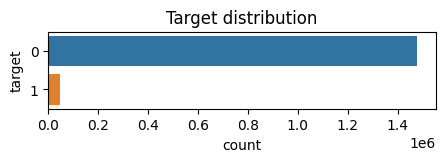

Targets == 1 are: 3.0% from train data


In [8]:
# Target distribution
plt.figure(figsize=(5, 1))
plt.title('Target distribution')
sns.countplot(data=plot_data, y='target')
plt.show()
print(f'Targets == 1 are: {plot_data.target.mean().round(2) * 100}% from train data')

* Target is unbalanced (97/3)

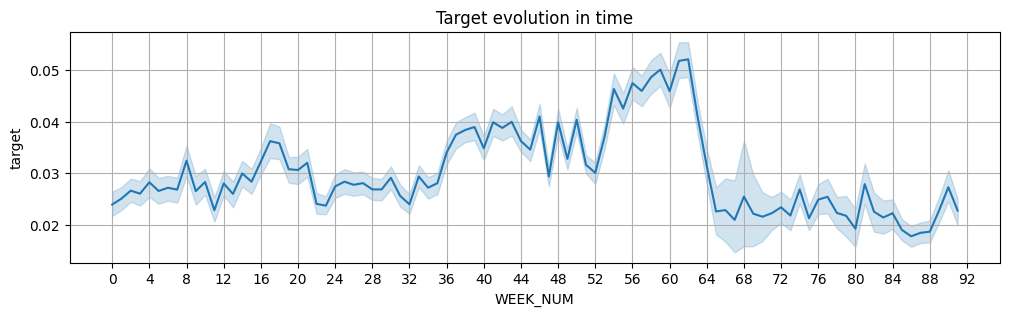

In [9]:
# Target evolution in time
plt.figure(figsize=(12, 3))
plt.title('Target evolution in time')
g = sns.lineplot(data=plot_data, x='WEEK_NUM', y='target')
g.set(xticks=np.arange(0, 93, 4))
plt.grid() 
plt.show()

* A big drop of total defaults was registered between weeks 62 - 65 

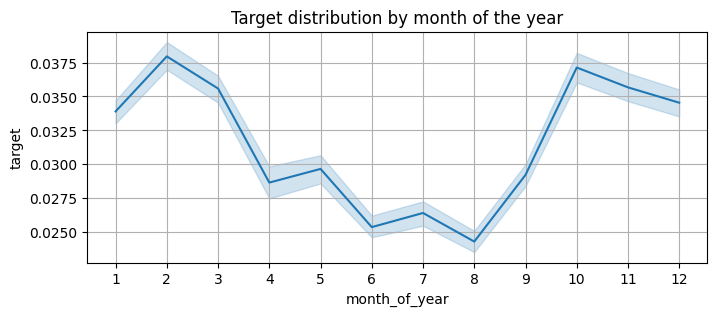

In [10]:
# Target distribution by month_of_year
plt.figure(figsize=(8, 3))
plt.title('Target distribution by month of the year')
g = sns.lineplot(data=plot_data, x='month_of_year', y='target')
g.set(xticks=np.arange(1, 13, 1))
plt.grid()
plt.show()

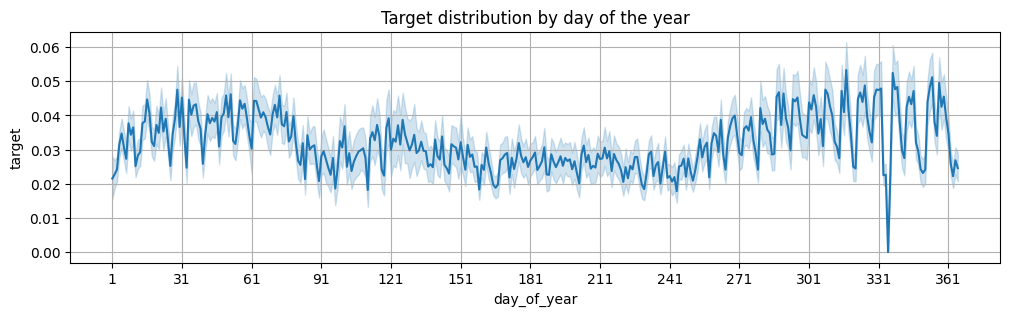

In [11]:
# Target distribution by day_of_year
plt.figure(figsize=(12, 3))
plt.title('Target distribution by day of the year')
g = sns.lineplot(data=plot_data, x='day_of_year', y='target')
g.set(xticks=np.arange(1, 366, 30))
plt.grid()
plt.show()

* Strange behaviour on day 335, the only day without any target == 1

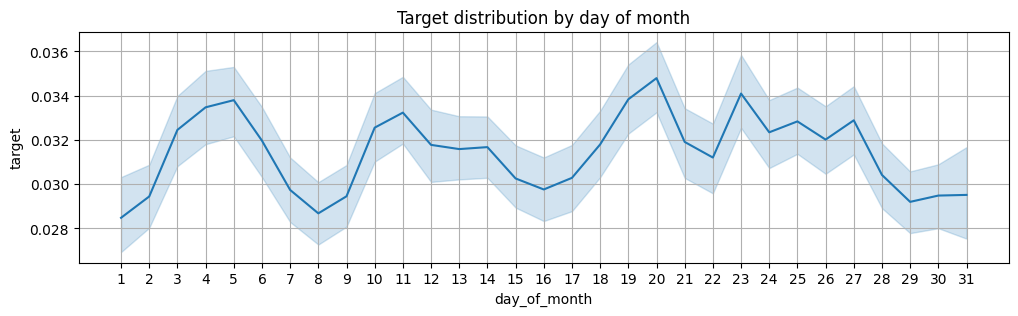

In [12]:
# Target distribution by day_of_month
plt.figure(figsize=(12, 3))
plt.title('Target distribution by day of month')
g = sns.lineplot(data=plot_data, x='day_of_month', y='target')
g.set(xticks=np.arange(1, 32, 1))
plt.grid()
plt.show()

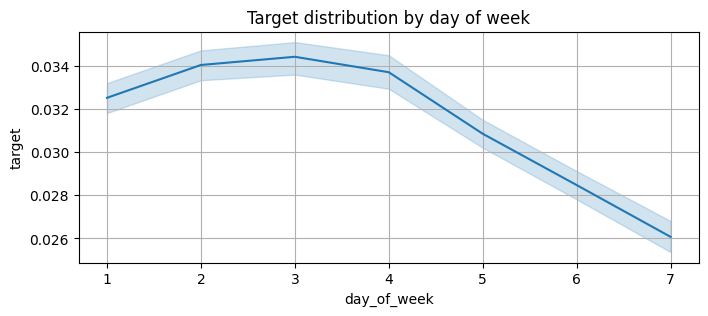

In [13]:
# Target distribution by day_of_week
plt.figure(figsize=(8, 3))
plt.title('Target distribution by day of week')
g = sns.lineplot(data=plot_data, x='day_of_week', y='target')
g.set(xticks=np.arange(1, 8, 1))
plt.grid()
plt.show()

In [14]:
# Free memory
del plot_data

In [15]:
# Check the weeks with the highest missing values ratio
df_missing = X.groupby('WEEK_NUM').case_id.count().reset_index()
df_missing = df_missing.rename(columns={'case_id': 'Count'})

for week in X.WEEK_NUM.unique():
    missing = X[X.WEEK_NUM.eq(week)].isna().sum().sum()
    size = X[X.WEEK_NUM.eq(week)].size
    df_missing.loc[df_missing.WEEK_NUM.eq(week), 'Missing_ratio'] = missing / size

df_missing.sort_values('Missing_ratio', ascending=False)

,WEEK_NUM,Count,Missing_ratio
0,0,16735,0.649385
2,2,17476,0.536394
1,1,18841,0.535349
3,3,16108,0.532419
4,4,14309,0.527747
...,...,...,...
84,84,9721,0.389028
83,83,7295,0.387152
82,82,5423,0.383946
81,81,6743,0.383068


* week 0 has very high missing ratio comparing to other weeks

In [16]:
# Check which weeks has the most maximum values by columns
max_df = X.select_dtypes(np.number).groupby('WEEK_NUM').max()
max_week_list = []
for col in max_df.columns:
    max_week = max_df.sort_values(col, ascending=False).iloc[0].name
    max_week_list.append(max_week)
max_week_df = pd.DataFrame(max_week_list)
max_week_df.value_counts()

0 
91    63
87    13
75    10
1      8
61     8
      ..
22     1
24     1
25     1
27     1
80     1
Name: count, Length: 75, dtype: int64

* weeks 0 and 91 have very much maximum values comparing to other weeks

#### Define pipeline transformers

In [17]:
class TimeFeatTransformer(BaseEstimator, TransformerMixin):
    """
    Transformer to create time related features
    """
    def fit(self, df, y=None):
        self.ref_cols = ['birth_259D_mean', 'date_decision']
        self.original_cols = [col for col in df.columns 
                              if col not in self.ref_cols]
        return self
    
    def transform(self, df):
        # Create time delta features
        for col in self.original_cols:
            delta_col_0 = f'delta_{col}_{self.ref_cols[0]}'
            df[delta_col_0] = abs(df[col] - df[self.ref_cols[0]]).dt.days

            delta_col_1 = f'delta_{col}_{self.ref_cols[1]}'
            df[delta_col_1] = abs(df[col] - df[self.ref_cols[1]]).dt.days
            
        delta_col_0_1 = f'delta_{self.ref_cols[1]}_{self.ref_cols[0]}'      
        df[delta_col_0_1] = abs(df[self.ref_cols[1]] - df[self.ref_cols[0]]).dt.days
        
        # Drop used cols 
        df = df.drop(self.ref_cols + self.original_cols, axis=1)
        
        self.delta_cols = df.columns.to_list()
        
        return df
   
    def get_feature_names_out(self, input_features=None):
        return self.delta_cols

class NumFeatTransformer(BaseEstimator, TransformerMixin):
    """
    Transformer to create numeric related features
    """
    def fit(self, df, y=None):
        self.ref_cols = ['birth_year', 'decision_year']
        self.year_cols = []
        for col in df.columns:
            if 'year' in col and 'T' in col:
                self.year_cols.append(col)
        return self
    
    def transform(self, df):
        # Create year delta features
        for col in self.year_cols:
            delta_col_0 = f'delta_{col}_{self.ref_cols[0]}'
            df[delta_col_0] = abs(df[col] - df[self.ref_cols[0]])

            delta_col_1 = f'delta_{col}_{self.ref_cols[1]}'
            df[delta_col_1] = abs(df[col] - df[self.ref_cols[1]])

        delta_col_0_1 = f'delta_{self.ref_cols[1]}_{self.ref_cols[0]}'   
        df[delta_col_0_1] = abs(df[self.ref_cols[1]] - df[self.ref_cols[0]])
        
        df = df.drop(self.ref_cols + self.year_cols, axis=1)
        
        self.all_cols = df.columns.to_list()

        return df.astype(float)
   
    def get_feature_names_out(self, input_features=None):
        return self.all_cols

class BadColsDropTransformer(BaseEstimator, TransformerMixin): 
    """
    Transformer to drop unuseful columns
    """
    def fit(self, df, y=None):
        # Columns with many missing values 
        self.missing_values = df.isna().mean().sort_values(ascending=False)
        self.cols_to_drop = set(
            self.missing_values[self.missing_values.gt(0.95)].index
        )
        # Columns with one higly dominant value
        for col in df.columns:
            if (df[col].value_counts(normalize=True) > 0.95).any():
                self.cols_to_drop.add(col)
                
        # Columns with identical values  
        for col1 in df.columns[:-1]:
            if col1 not in self.cols_to_drop:
                for col2 in df.columns[df.columns.get_loc(col1) + 1:]:
                    if df[col1].equals(df[col2]):
                        self.cols_to_drop.add(col2)
        return self
        
    def transform(self, df):
        return df.drop(list(self.cols_to_drop), axis=1)
    
    def get_feature_names_out(self, input_features=None):
        return [col for col in input_features 
                if col not in self.cols_to_drop]
    
class HighCorrDropTransformer(BaseEstimator, TransformerMixin):
    """
    Transformer to drop highly correlated numerical columns
    """
    def fit(self, df, y=None):
        self.corr_matrix = df.corr()
        self.cols_to_drop = set()
        for col1 in self.corr_matrix.columns:
            for col2 in self.corr_matrix.columns:
                if col1 != col2:
                    # Check for high correlation
                    if abs(self.corr_matrix.loc[col1, col2]) >= 0.90:
                        # Check which column has more missing values
                        if df[col1].isna().sum() > df[col2].isna().sum():
                            self.cols_to_drop.add(col1)
                        else:
                            self.cols_to_drop.add(col2) 
        return self
    
    def transform(self, df):
        return df.drop(list(self.cols_to_drop), axis=1)
    
    def get_feature_names_out(self, input_features=None):
        return [col for col in input_features if col not in self.cols_to_drop]
        
class LowFreqTransformer(BaseEstimator, TransformerMixin):
    """
    Transformer to process categorical, boolean and object columns
    Fill missing and convert infrequent values
    """
    def fit(self, df, y=None):
        self.original_cols = df.columns
        self.frequencies = {}
        self.threshold = {}
        for col in df.columns:
            self.frequencies[col] = df[col].value_counts(normalize=True, 
                                                         ascending=True)
            self.threshold[col] = self.frequencies[col][
                (self.frequencies[col].cumsum() > 0.05).idxmax()
                ]
        return self
    
    def transform(self, df):
        for col in self.original_cols:
            df[col] = df[col].astype(str)
            
            infrequent_mask = (df[col].isin(
                self.frequencies[col].index[
                    self.frequencies[col] < self.threshold[col]
                ]))
            # Convert low frequency categoricals to 'infrequent'
            df.loc[infrequent_mask, col] = 'infrequent'
        return df
    
    def get_feature_names_out(self, input_features=None):
        return input_features

#### Processing pipeline

In [18]:
# Drop outlier weeks after analysis
X = X[~X.WEEK_NUM.eq(0)]

# Drop day 335 as an outlier, the only date without any target=1
X = X[~X['date_decision'].dt.dayofyear.eq(335)]

# Separate target
y = X.pop('target')

# Keep a copy of WEEK_NUM for group splitting in modeling
week_num = X.WEEK_NUM

# Drop unuseful and duplicate columns
cols_to_drop = [
    'case_id', 'MONTH', 'WEEK_NUM', 'birthdate_574D', 'dateofbirth_337D',  
]
X = X.drop(cols_to_drop, axis=1)

# Keep the structure of X to match it later with X_test 
X_structure = X.drop(X.index)

X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1509873 entries, 100 to 1526658
Columns: 485 entries, actualdpdtolerance_344P to decision_day_of_week
dtypes: Int8(1), bool(1), category(113), datetime64[ms](56), float32(297), int16(3), int8(2), object(12)
memory usage: 2.7+ GB


In [19]:
# Separate columns by type
date_cols, num_cols, cat_cols = cols_types(X)
cat_unique = X[cat_cols].nunique()
low_card_cols = list(cat_unique.index[cat_unique.le(12)])
med_card_cols = list(cat_unique.index[cat_unique.gt(12) & cat_unique.le(200)])
high_card_cols = list(cat_unique.index[cat_unique.gt(200)])

# Pipeline to process date columns
date_pipeline = make_pipeline(
    TimeFeatTransformer(),
    BadColsDropTransformer(),
    HighCorrDropTransformer(),
    PowerTransformer(copy=False),
    )
# Pipeline to process numerical columns
num_pipeline = make_pipeline(
    NumFeatTransformer(),
    BadColsDropTransformer(),
    HighCorrDropTransformer(),
    PowerTransformer(copy=False),
    )
# Pipeline to process low cardinality columns
low_card_pipeline = make_pipeline(
    BadColsDropTransformer(),
    LowFreqTransformer(),
    OneHotEncoder(
        dtype=np.int8, drop='if_binary', sparse_output=False,
        min_frequency=0.02, handle_unknown='infrequent_if_exist'),
    )
# Pipeline to process medium cardinality columns
med_card_pipeline = make_pipeline(
    BadColsDropTransformer(),
    LowFreqTransformer(),
    OrdinalEncoder(handle_unknown='use_encoded_value',
                   unknown_value=np.nan,
                   dtype=np.float32),
    )
# Pipeline to process high cardinality columns
high_card_pipeline = make_pipeline(
    BadColsDropTransformer(),
    LowFreqTransformer(),
    TargetEncoder(target_type='binary', smooth='auto', shuffle=True),
    PowerTransformer(copy=False),
    )
# Define column transformer
processor = make_column_transformer(
    (date_pipeline, date_cols),
    (num_pipeline, num_cols),
    (low_card_pipeline, low_card_cols),
    (med_card_pipeline, med_card_cols),
    (high_card_pipeline, high_card_cols),
    verbose=True,
    )
processor

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('timefeattransformer',
                                                  TimeFeatTransformer()),
                                                 ('badcolsdroptransformer',
                                                  BadColsDropTransformer()),
                                                 ('highcorrdroptransformer',
                                                  HighCorrDropTransformer()),
                                                 ('powertransformer',
                                                  PowerTransformer(copy=False))]),
                                 ['date_decision', 'datefirstoffer_1144D',
                                  'datelastinstal40dpd_247D',
                                  'datelastunpaid_3...
                                  'district_544M_mode', 'profession_152M_mode',
                                  'contaddr_district_15M_mode',
                                  'contaddr_zipcode_807M_mode',
                                  'empladdr_district_926M_mode',
                                  'empladdr_zipcode_114M_mode',
                                  'registaddr_district_1083M_mode',
                                  'registaddr_zipcode_184M_mode',
                                  'name_4527232M_mode', 'name_4917606M_mode',
                                  'employername_160M_mode',
                                  'addres_district_368M_mode_mode',
                                  'addres_zip_823M_mode_mode'])],
                  verbose=True)

In [20]:
%%time 
# Train / validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8, stratify=y)
del X, y

# Process data
X_train = pd.DataFrame(processor.fit_transform(X_train, y_train), 
                       columns=processor.get_feature_names_out(),
                       index=X_train.index)
X_val = pd.DataFrame(processor.transform(X_val), 
                     columns=processor.get_feature_names_out(),
                     index=X_val.index)   

# Free memory
X_train = downcast(X_train)
X_val = downcast(X_val)  

# Convert med_card_cols to category to pass them unencoded to the model 
enc_med_card_cols = []
for col in med_card_cols:
    if 'pipeline-4__' + col in X_train.columns:
        enc_med_card_cols.append('pipeline-4__' + col)

X_train[enc_med_card_cols] = X_train[enc_med_card_cols].astype('str').astype('category')
X_val[enc_med_card_cols] = X_val[enc_med_card_cols].astype('str').astype('category')

X_train.info()

[ColumnTransformer] .... (1 of 5) Processing pipeline-1, total= 2.0min
[ColumnTransformer] .... (2 of 5) Processing pipeline-2, total= 8.9min
[ColumnTransformer] .... (3 of 5) Processing pipeline-3, total=  53.4s
[ColumnTransformer] .... (4 of 5) Processing pipeline-4, total=   5.5s
[ColumnTransformer] .... (5 of 5) Processing pipeline-5, total=  12.3s
<class 'pandas.core.frame.DataFrame'>
Index: 1207898 entries, 322840 to 257869
Columns: 423 entries, pipeline-1__delta_datefirstoffer_1144D_date_decision to pipeline-5__employername_160M_mode
dtypes: category(12), float32(411)
memory usage: 1.9 GB
CPU times: user 14min 27s, sys: 13.1 s, total: 14min 40s
Wall time: 13min 25s


#### Optuna tuning

In [25]:
def create_model(model_type, params):
    '''
    Create model instance
    '''
    models = {'lgb': LGBMClassifier, 
              'xgb': XGBClassifier, 
              'cb': CatBoostClassifier,
             }
    return models[model_type](**params)
    
class StabilityMetric:
    """
    Stability metric for model optimization during training
    """
    def __init__(self, model_type, week_num, X_val):
        self.model_type = model_type
        self.X_val = X_val
        self.week_num = week_num       

    def metric_func(self, y_true, y_pred):
        gini_in_time = []
        weeks_to_score = self.week_num[self.X_val.index].reset_index(drop=True)
        
        for week in weeks_to_score.unique():
            week_idx = weeks_to_score.eq(week)
            gini = 2 * roc_auc_score(y_true[week_idx], y_pred[week_idx]) - 1
            gini_in_time.append(gini)
            
        w_fallingrate = 88.0
        w_resstd = -0.5
        x = np.arange(len(gini_in_time))
        y = np.array(gini_in_time)
        a, b = np.polyfit(x, y, 1)
        y_hat = a * x + b
        residuals = y - y_hat
        res_std = np.std(residuals)
        avg_gini = np.mean(y)
        stability_score = avg_gini + w_fallingrate * min(0, a) + w_resstd * res_std
        
        if self.model_type == 'lgb':
            is_higher_better = True
            return 'stability_score', stability_score, is_higher_better
        else:
            return 'stability_score', stability_score

def model_objective(trial, model_type, X_train, y_train, X_val, y_val, 
                    cat_cols, week_num, device='gpu'):
    """
    Objective function for hyperparameter tuning
    """ 
    # Target ratio
    y_ratio = np.sum(y_train == 0) / np.sum(y_train == 1)
    
    # Define hyperparameter search space
    if model_type == 'lgb':
        tune_params = {      
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 8, 256),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 200),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'subsample_freq': trial.suggest_int('subsample_freq', 0, 10),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, y_ratio*2, log=True),

            'n_estimators': 3000,
            'objective': 'binary',
            'metric': 'None',
            'verbosity': -1,
            'device': device,
            'max_bin': 255,
            'n_jobs': -1,
            }
    elif model_type == 'xgb':
        tune_params = { 
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.3, y_ratio*3, log=True),

            'n_estimators': 3000,
            'early_stopping_rounds': 50,
            'objective': 'binary:logistic',
            'enable_categorical': True,
            'verbosity': 0, 
            'device': 'cuda' if device == 'gpu' else 'cpu',
            'n_jobs': -1,
            } 
    elif model_type == 'cb':
        tune_params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 1e-8, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'rsm': trial.suggest_float('rsm', 0.5, 1.0),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.3, y_ratio*3, log=True),

            'iterations': 3000,
            'early_stopping_rounds': 50,
            'cat_features': cat_cols, 
            'objective': 'Logloss', 
            'task_type': device.upper(),
            'border_count': 128 if device == 'gpu' else 254,
            'verbose': 0, 
            'thread_count': -1,
        } 
    stability_metric = StabilityMetric(model_type, week_num, X_val)    
    model = create_model(model_type, tune_params)

    if model_type == 'lgb':
        model.fit(X_train, y_train, 
                  eval_set=[(X_val, y_val)],
                  eval_metric=stability_metric.metric_func,
                  callbacks=[early_stopping(50)],
                 ) 
        y_pred = model.predict_proba(X_val)[:, 1]
        _, stability_score, _ = stability_metric.metric_func(
            np.array(y_val), np.array(y_pred)
        )
    else:
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
        y_pred = model.predict_proba(X_val)[:, 1]
        _, stability_score = stability_metric.metric_func(
            np.array(y_val), np.array(y_pred)
        )
    return stability_score

In [26]:
%%time
# Optuna study
optuna_model = None # Set to 'lgb', 'xgb', 'cb', or None to skip

if optuna_model != None:
    # Define objective function with closure
    def objective(trial):
        return model_objective(
            trial, optuna_model, X_train, y_train, X_val, y_val, 
            enc_med_card_cols, week_num, device,
        )
    # Optuna study
    sampler = optuna.samplers.TPESampler(multivariate=True, seed=42)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=50, timeout=60*60*12)  # 12 hours timeout

    # Show best results
    trial = study.best_trial
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    print(f'Number of completed trials: {len(completed_trials)}')
    print(f'Best score: {trial.value:.3f}')
    print(f'Best params: {trial.params}')

[I 2025-11-21 13:25:20,705] A new study created in memory with name: no-name-fa86e16b-238e-498d-b4d0-a5177da1db3c
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[292]	valid_0's stability_score: 0.677452


[I 2025-11-21 13:29:07,330] Trial 0 finished with value: 0.6774524381563042 and parameters: {'learning_rate': 0.03574712922600244, 'num_leaves': 244, 'min_child_samples': 148, 'reg_alpha': 0.0024430162614261413, 'reg_lambda': 2.5361081166471375e-07, 'colsample_bytree': 0.49359671220172163, 'subsample': 0.5290418060840998, 'subsample_freq': 9, 'scale_pos_weight': 11.88776889599969}. Best is trial 0 with value: 0.6774524381563042.


Training until validation scores don't improve for 50 rounds


[W 2025-11-21 13:29:29,768] Trial 1 failed with parameters: {'learning_rate': 0.11114989443094977, 'num_leaves': 13, 'min_child_samples': 195, 'reg_alpha': 0.31044435499483225, 'reg_lambda': 8.148018307012941e-07, 'colsample_bytree': 0.5090949803242604, 'subsample': 0.5917022549267169, 'subsample_freq': 3, 'scale_pos_weight': 8.680250354268889} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "<timed exec>", line 7, in objective
  File "/tmp/ipykernel_136/1769191995.py", line 120, in model_objective
    model.fit(X_train, y_train,
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
                    ^^^^^^
  

KeyboardInterrupt: 

#### Models' best parameters

In [27]:
# LGBM best parameters
lgbm_params = {
    'num_leaves': 214, 
    'min_data_in_leaf': 1831, 
    'learning_rate': 0.018016752095308213, 
    'lambda_l1': 0.039542276491157664, 
    'lambda_l2': 0.0028839017821387612, 
    'feature_fraction': 0.8606139936996, 
    'bagging_fraction': 0.6505054297397137,
    'bagging_freq': 4,
    'scale_pos_weight': 30.72,

    'n_estimators': 3000,
    'objective': 'binary',
    'metric': 'None', # stability metric is used as eval_metric
    'verbosity': -1,
    'device': device,
    'max_bin': 255,
    'n_jobs': -1,
    }
# XGB best parameters
xgb_params = {
    'learning_rate': 0.02563139404535397, 
    'max_depth': 17, 
    'min_child_weight': 1446, 
    'max_delta_setp': 0,
    'subsample': 0.8564298564731834, 
    'colsample_bytree': 0.9235898601649664, 
    'reg_lambda': 1.1289608466365559e-08, 
    'reg_alpha': 4.911518931389214e-07, 
    'gamma': 0.00035869889925144383, 
    'scale_pos_weight': 30.72,

    'n_estimators': 3000,
    'early_stopping_rounds': 50,
    'objective': 'binary:logistic',
    'enable_categorical': True,
    'verbosity': 0, 
    'device': 'cuda' if device == 'gpu' else 'cpu',
    'n_jobs': -1,
    }
# CatBoost best parameters
cb_params = { 
    'learning_rate': 0.08, 
    'l2_leaf_reg': 57.87508612048416, 
    'bagging_temperature': 0.737099486243173, 
    'random_strength': 0.0017723437301297412, 
    'depth': 6, 
    'min_data_in_leaf': 66,
    'scale_pos_weight': 30.72,

    'iterations': 2000,
    'early_stopping_rounds': 50,
    'cat_features': enc_med_card_cols, 
    'objective': 'Logloss', 
    'task_type': device.upper(),
    'border_count': 128 if device == 'gpu' else 254,
    'verbose': 0, 
    'thread_count': -1,
    }

#### Create model

In [28]:
def train_model(X_train, y_train, X_val, y_val, model_type, params, week_num):
    """
    Train a specific model type with predefined parameters
    """
    stability_metric = StabilityMetric(model_type, week_num, X_val) 
    model = create_model(model_type, params)

    if model_type == 'lgb':
        model.fit(X_train, y_train, 
                  eval_set=[(X_val, y_val)],
                  eval_metric=stability_metric.metric_func,
                  callbacks=[early_stopping(50)],
                 ) 
    else:
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
        
    return model

In [32]:
%%time

# Train model
X_train, y_train = shuffle(X_train, y_train)
lgbm_model = train_model(X_train, y_train, X_val, y_val, 'lgb', lgbm_params, week_num)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[824]	valid_0's stability_score: 0.686429
CPU times: user 20min 51s, sys: 5.45 s, total: 20min 56s
Wall time: 8min 10s


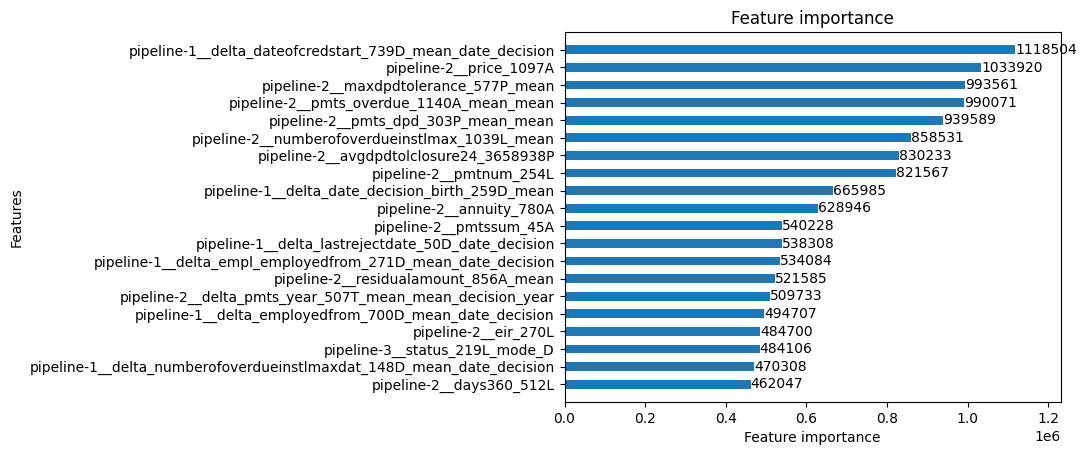

In [33]:
# Plot LGBM model features importance
plot_importance(lgbm_model, 
                importance_type='gain', 
                max_num_features=20, 
                height=0.5,
                grid=False,
                precision=0,
                )
plt.show()

#### Read and prepare test set

In [34]:
# Free memory
del X_train, X_val, y_train, y_val

# Read, preprocess and merge all the test files together
X_test = read_prepare_all(test_path, files_dict)

# Match X_test columns with X columns
for col in X_structure.columns:
    if col not in X_test.columns:
        X_test[col] = X_structure[col]
        print(f'{col} added to X_test')
        
X_test = X_test[X_structure.columns]

X_test.info()

Chunk 0 added to list
base created
### Start read static_0
Chunk 0 added to list
Chunk 1 added to list
Chunk 2 added to list
=== static_0 merged to df_all
### Start read static_cb_0
Chunk 0 added to list
=== static_cb_0 merged to df_all
### Start read credit_bureau_a_1
Depth1 aggregation finished
Chunk 0 added to list
Depth1 aggregation finished
Chunk 1 added to list
Depth1 aggregation finished
Chunk 2 added to list
Depth1 aggregation finished
Chunk 3 added to list
Depth1 aggregation finished
Chunk 4 added to list
=== credit_bureau_a_1 merged to df_all
### Start read credit_bureau_b_1
Depth1 aggregation finished
Chunk 0 added to list
=== credit_bureau_b_1 merged to df_all
### Start read applprev_1
Depth1 aggregation finished
Chunk 0 added to list
Depth1 aggregation finished
Chunk 1 added to list
Depth1 aggregation finished
Chunk 2 added to list
=== applprev_1 merged to df_all
### Start read debitcard_1
Depth1 aggregation finished
Chunk 0 added to list
=== debitcard_1 merged to df_all
#

#### Predict and submit

In [35]:
def predict_proba_in_batches(X_test, final_model, batch_size=10000):
    """
    Process the test set and predict in batches
    """
    num_samples = len(X_test)
    num_batches = (num_samples // batch_size) + 1
    y_pred = []
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, num_samples)
        X_batch = X_test.iloc[start_idx:end_idx]
        X_batch = pd.DataFrame(
            processor.transform(X_batch), 
            columns=processor.get_feature_names_out(),
            index=X_batch.index)
        X_batch[enc_med_card_cols] = (X_batch[enc_med_card_cols]
                                      .astype(str).astype('category'))
        batch_preds = []
        
        for model_type, model in final_model.items():
            if 'single' in model_type:
                batch_model_preds = model.predict_proba(X_batch)[:, 1]

            elif 'ensemble' in model_type: 
                # Predict the average from a list of estimators
                batch_model_preds = mean_predict_proba(
                    X_batch, estimators=model)
                
            batch_preds.append(batch_model_preds)
            
        batch_preds = np.vstack(batch_preds)
        y_pred.append(batch_preds) 
        
    # The average from all predictions
    y_pred = np.hstack(y_pred)
    y_pred = np.mean(y_pred, axis=0) 
        
    return y_pred

In [36]:
# Predict
final_model = {
    'single': lgbm_model,
#     'single': xgb_model,
#     'ensemble': lgbm_bag_week_model,
}
y_pred = predict_proba_in_batches(X_test, final_model, batch_size=10000)

# Submit
submit = pd.read_csv(main_path + 'sample_submission.csv')
submit.score = y_pred

submit.to_csv('submission.csv', index=False)

submit

,case_id,score
0,57543,0.063732
1,57549,0.408924
2,57551,0.009432
3,57552,0.252517
4,57569,0.630620
5,57630,0.035381
6,57631,0.132236
7,57632,0.020213
8,57633,0.226313
9,57634,0.182521
